<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html week5.do.txt --no_mako -->
<!-- dom:TITLE: February 12-16,2024: Quantum Computing, Quantum Machine Learning and Quantum Information Theories -->

# February 12-16,2024: Quantum Computing, Quantum Machine Learning and Quantum Information Theories
**Morten Hjorth-Jensen**, Department of Physics, University of Oslo and Department of Physics and Astronomy and National Superconducting Cyclotron Laboratory, Michigan State University

Date: **February 14**

## Plans for the week of February 12-16
1. Quantum circuits and operations (one-, two- and three-qubit gates

2. Hands-on exercises, see end of these slides

3. Discussion of the first iteration of project 1

4. [Video of lecture](https://youtu.be/9XrDKgTQL6I)

5. [Whiteboard notes](https://github.com/CompPhysics/QuantumComputingMachineLearning/blob/gh-pages/doc/HandWrittenNotes/2024/NotesFebruary14.pdf)

## Running on the IBM machines

For the projects and exercises, using for example Qiskit, we can run (as of now) on IBM's 127 qubit machine (Osaka).
The Bell-state simulations below here perform this. To get started with the IBM machines, you need an account. Here's the recipe you need to follow:
1. Go to <quantum.ibm.com> and create an account and follow the instructions.

2. After you have set up your account, go to the account icon and find the token. You need this to identify your self when running jobs. See the code example below.

3. Clicking on the **jobs** link you can see which machines are availbale and where your job is, whether it is a queue or whether it is pending.

The example at the end of this week's slides shows you how can run on IBM-Osaka, the 127 qubit machine which is presently available.
Make sure you copy in your own token,  as that is your unique identifier.

## Explicit instructions

In [1]:
# Install qiskit and various packages
pip install -q qiskit
pip install -q qiskit-aer
pip install -q qiskit-ibmq-provider

## Setting up your IBM run

In [2]:
# Provide your IBM Quantum Experience API token here
# Paste in this from your IBM account
api_token = 'your_api_token'
# Load your IBM Quantum account
IBMQ.save_account(api_token, overwrite=True)  # This stores your credentials locally
IBMQ.load_account()
# Get the least busy backend
provider = IBMQ.get_provider(hub='ibm-q', group ='open', project='main')
# Run on the 127-qubit machine IBM-Osaka
backend = provider.get_backend('ibm_osaka')
# Create a quantum circuit with two qubits
bell_circuit = QuantumCircuit(2, 2)

## Quantum gates, circuits and simple algorithms

Quantum gates are physical actions that are applied to the physical
system representing the qubits. Mathematically, they are
complex-valued, unitary matrices which act on the complex-values
normalized vectors that represent qubits. As the quantum analog of
classical logic gates (such as AND and OR), there is a corresponding
quantum gate for every classical gate; however, there are quantum
gates that have no classical counter-part. They act on a set of qubits
and, changing their state. That is, if $U$ is a quantum gate and
$\vert q \rangle $ is a qubit, then acting the gate $U$ on the qubit $\vert q \rangle $
transforms the qubit as follows:

<!-- Equation labels as ordinary links -->
<div id="_auto1"></div>

$$
\begin{equation}
\vert q \rangle \overset{U}{\to}U\vert q \rangle 
. \label{_auto1} \tag{1}
\end{equation}
$$

## Quantum circuits

Quantum circuits are diagrammatic representations of quantum
algorithms. The horizontal dimension corresponds to time; moving left
to right corresponds to forward motion in time. They consist of a set
of qubits $\vert q_n\rangle$ which are stacked vertically on the left-hand
side of the diagram. Lines, called quantum wires, extend horizontally
to the right from each qubit, representing its state moving forward in
time. Additionally, they contain a set of quantum gates that are
applied to the quantum wires. Gates are applied chronologically, left
to right.

## Single-Qubit Gates

A single-qubit gate is a physical action that is applied to one
qubit. It can be represented by a matrix $U$ from the group SU(2). Any
single-qubit gate can be parameterized by three angles: $\theta$,
$\phi$, and $\lambda$ as follows

$$
U(\theta,\phi,\lambda)=\begin{bmatrix}
\cos\frac{\theta}{2} & -e^{i\lambda}\sin\frac{\theta}{2}
\\
e^{i\phi}\sin\frac{\theta}{2} & e^{i(\phi+\lambda)}\cos\frac{\theta}{2}
\end{bmatrix}.
$$

## Widely used gates

There are several widely used quantum gates. Perhaps the most famous are 
the Pauli gates correspond to the Pauli matrices

$$
I=\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix},
$$

$$
X =\begin{bmatrix} 0 & 1 \\ 1 & 0\end{bmatrix},
$$

$$
Y=\begin{bmatrix}0 & -i \\i & 0\end{bmatrix},
$$

$$
Z=\begin{bmatrix} 1 & 0 \\ 0 & -1\end{bmatrix}.
$$

## Algebra basis

These gates form a basis for
the algebra $\mathfrak{su}(2)$. Exponentiating them will thus give us
a basis for SU(2), the group within which all single-qubit gates
live.

## Exponentiated Pauli gates

These exponentiated Pauli gates are called rotation gates
$R_{\sigma}(\theta)$ because they rotate the quantum state around the
axis $\sigma=X,Y,Z$ of the Bloch sphere by an angle $\theta$. They are
defined as

$$
R_X(\theta)=e^{-i\frac{\theta}{2}X}=
\begin{bmatrix}
\cos\frac{\theta}{2} & -i\sin\frac{\theta}{2} \\
-i\sin\frac{\theta}{2} & \cos\frac{\theta}{2} 
\end{bmatrix},
$$

$$
R_Y(\theta)=e^{-i\frac{\theta}{2}Y}=
\begin{bmatrix}
\cos\frac{\theta}{2} & -\sin\frac{\theta}{2} \\
\sin\frac{\theta}{2} & \cos\frac{\theta}{2} 
\end{bmatrix},
$$

$$
R_Z(\theta)=e^{-i\frac{\theta}{2}Z}=\begin{bmatrix}
e^{-i\theta/2} & 0 \\
0 & e^{i\theta/2}\end{bmatrix}.
$$

## Basis for $\mathrm{SU}(2)$

Because they form a basis for $\mathrm{SU}(2)$, any single-qubit gate
can be decomposed into three rotation gates. Indeed

$$
R_z(\phi)R_y(\theta)R_z(\lambda)=
\begin{bmatrix}
e^{-i\phi/2} & 0 \\
0 & e^{i\phi/2}
\end{bmatrix}
\begin{bmatrix}
\cos\frac{\theta}{2} & -\sin\frac{\theta}{2} \\
\sin\frac{\theta}{2} & \cos\frac{\theta}{2} 
\end{bmatrix}
\begin{bmatrix}
e^{-i\lambda/2} & 0 \\
0 & e^{i\lambda/2}
\end{bmatrix}
$$

which we can rewite as

$$
e^{-i(\phi+\lambda)/2}
\begin{bmatrix}
\cos\frac{\theta}{2} & -e^{i\lambda}\sin\frac{\theta}{2}\\
e^{i\phi}\sin\frac{\theta}{2} & e^{i(\phi+\lambda)}\cos\frac{\theta}{2}
\end{bmatrix},
$$

which is, up to a global phase, equal to the expression for an arbitrary single-qubit gate.

## Two-Qubit Gates

A two-qubit gate is a physical action that is applied to two
qubits. It can be represented by a matrix $U$ from the group
SU(4). One important type of two-qubit gates are controlled gates,
which work as follows: Suppose $U$ is a single-qubit gate. A
controlled-$U$ gate ($CU$) acts on two qubits: a control qubit
$\vert x \rangle $ and a target qubit $\vert y \rangle $. The controlled-$U$ gate
applies the identity $I$ or the single-qubit gate $U$ to the target
qubit if the control gate is in the zero state $\vert 0\rangle$ or the one
state $\vert 1\rangle$, respectively.

## Control qubit
The control qubit is not acted
upon. This can be represented as follows if

$$
CU\vert xy\rangle=
\vert xy\rangle \hspace{0.1cm} \mathrm{if} \hspace{0.1cm}  \vert x \rangle =\vert 0\rangle.
$$

## In matrix form

It is easier to see in a matrix form.
It can be written in matrix form by writing it as a superposition of
the two possible cases, each written as a simple tensor product

$$
CU = \vert 0\rangle\langle 0\vert\otimes I + \vert 1\rangle\langle 1 \vert \otimes U=\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & u_{00} & u_{01} \\
0 & 0 & u_{10} & u_{11}
\end{bmatrix}.
$$

## CNOT gate

One of the most fundamental controlled gates is the CNOT gate. It is
defined as the controlled-$X$ gate $CX$. It can be written in matrix form as follows:

$$
\mathrm{CNOT}=\mathrm{CX}=\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{bmatrix}.
$$

## $\mathrm{CX}$ gate

It changes, when operating on a two-qubit state where the first qubit is the control qubit and the second qubit is the target qubit, the states (check this)

$$
\mathrm{CX}\vert 00\rangle=\vert 00\rangle,
$$

$$
\mathrm{CX}\vert 10\rangle= \vert 11\rangle,
$$

$$
\mathrm{CX}\vert 01\rangle= \vert 01\rangle,
$$

$$
\mathrm{CX}\vert 11\rangle= \vert 10\rangle,
$$

which you can easily see by simply multiplying the above matrix with any of the above states.

## Swap gate

A widely used two-qubit gate that goes beyond the simple controlled function is the SWAP gate. It swaps the states of the two qubits it acts upon

$$
\mathrm{SWAP}\vert xy\rangle=\vert yx\rangle.
$$

and has the following matrix form

$$
\mathrm{SWAP}
=\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}.
$$

## Introduction to [Qiskit](https://qiskit.org/)

This part is best seen using the jupyter-notebook.

For the installation

In [3]:
pip install qiskit
pip install qiskit-ibm-runtime

Documentation can be found at <https://docs.quantum.ibm.com/api/qiskit >

## Simple code

In [2]:
#!/usr/bin/env python
# coding: utf-8
import numpy as np
import qiskit as qk
from scipy.optimize import minimize


# # Initialize registers and circuit

n_qubits = 1 #Number of qubits
n_cbits = 1 #Number of classical bits (the number of qubits you want to measure at the end of the circuit)
qreg = qk.QuantumRegister(n_qubits) #Create a quantum register
creg = qk.ClassicalRegister(n_cbits) #Create a classical register
circuit = qk.QuantumCircuit(qreg,creg) #Create your quantum circuit


circuit.draw() #Draw circuit. It is empty

q1: 
      
c1: 1/

Thereafter we perform operations on qubit

In [3]:
circuit.x(qreg[0]) #Applies a Pauli X gate to the first qubit in the quantum register
circuit.draw()

┌───┐
  q1: ┤ X ├
      └───┘
c1: 1/═════

and select  a qubit to measure and encode the results to a classical bit

In [4]:
#Measure the first qubit in the quantum register
#and encode the results to the first qubit in the classical register
circuit.measure(qreg[0],creg[0])
circuit.draw()

┌───┐┌─┐
  q1: ┤ X ├┤M├
      └───┘└╥┘
c1: 1/══════╩═
            0

Thereafter we execute the circuit

In [5]:
backend = qk.Aer.get_backend('qasm_simulator') 
#This is the device you want to use. It is an ideal simulation of a quantum device


job = backend.run(circuit,shots=1000) #Run the circuit 1000 times
result = job.result()
counts = result.get_counts()
print(counts)
circuit.clear()
circuit.draw()


circuit.h(qreg[0]) #Apply a Hadamard gate to the first qubit of the quantum register
circuit.measure(qreg,creg)
print(circuit.draw())


job = backend.run(circuit,shots=1000)
result = job.result()
counts = result.get_counts()
print(counts)
circuit.clear()

{'1': 1000}
      ┌───┐┌─┐
  q1: ┤ H ├┤M├
      └───┘└╥┘
c1: 1/══════╩═
            0 
{'0': 481, '1': 519}


/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_76554/632183382.py:1: DeprecationWarning: The 'qiskit.Aer' entry point is deprecated and will be removed in Qiskit 1.0. You should use 'qiskit_aer.Aer' directly instead.
  backend = qk.Aer.get_backend('qasm_simulator')


Now we create a two-qubit circuit and set up a Bell state

In [6]:
n_qubits = 2
n_cbits = 2
qreg = qk.QuantumRegister(n_qubits)
creg = qk.ClassicalRegister(n_cbits)
circuit = qk.QuantumCircuit(qreg,creg)
circuit.draw()



circuit.h(qreg[0])
circuit.cx(qreg[0],qreg[1]) 
#This is a controlled operation. Apply a Pauli X gate to the second qubit (qreg[1]) if the first qubit (qreg[0])
#is in the |1> state. Else do nothing

circuit.draw()

circuit.measure(qreg,creg)
circuit.draw()

┌───┐     ┌─┐   
q2_0: ┤ H ├──■──┤M├───
      └───┘┌─┴─┐└╥┘┌─┐
q2_1: ─────┤ X ├─╫─┤M├
           └───┘ ║ └╥┘
c2: 2/═══════════╩══╩═
                 0  1

In [7]:
job = backend.run(circuit,shots=1000)
result = job.result()
counts = result.get_counts()
print(counts)
circuit.clear()

{'11': 505, '00': 495}


We apply a rotation to a qubit

In [8]:
theta = np.pi/3
circuit.rx(theta, qreg[0]) #R_x(theta) rotation on the first qubit (qreg[0])
circuit.measure(qreg,creg)
print(circuit.draw())
job = backend.run(circuit,shots=1000)
result = job.result()
counts = result.get_counts()
circuit.clear()
print(counts)

      ┌─────────┐┌─┐
q2_0: ┤ Rx(π/3) ├┤M├
      └───┬─┬───┘└╥┘
q2_1: ────┤M├─────╫─
          └╥┘     ║ 
c2: 2/═════╩══════╩═
           1      0 
{'01': 251, '00': 749}


## Exercises on Bell states, developed by Keran

In [9]:
%matplotlib inline

import qiskit as qk
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

Setting up a circuit

In [10]:
qreg_q = QuantumRegister(2) # 2 qubits
creg_c = ClassicalRegister(2) # 2 classical bits

qc = QuantumCircuit(qreg_q, creg_c) # alternatively, circuit = QuantumCircuit(2, 2)

qc.h(qreg_q[0]) # apply the hadamard gate to the first qubit (to the right)

# apply the CNOT gate with the first qubit being the control qubit and the second qubit being the target qubit
qc.cx(qreg_q[0], qreg_q[1]) 


# measure the qubits, specify which qubit you want to measure
qc.measure(qreg_q[0], creg_c[0])
qc.measure(qreg_q[1], creg_c[1])

Next we will use an ideal(noiseless) simulator (AerSimulator) to run
our circuit. We will use the qasm$\_$simulator backend. This simulator
returns a result object which contains the counts, or number of times
each qubit was measured in the zero state and the one state. We can
then use the plot$\_$histogram function to see the result of our circuit.

In [11]:
# Initialize a simulator
simulator = AerSimulator()

job = qk.execute(qc, simulator, shots=1000) # shots are the number of times the circuit is executed
results = job.result().get_counts(qc) # Done! check out the results!
print(results)

{'11': 508, '00': 492}


/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_76554/1116729268.py:4: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = qk.execute(qc, simulator, shots=1000) # shots are the number of times the circuit is executed


Is this what you expected? Visualise it!

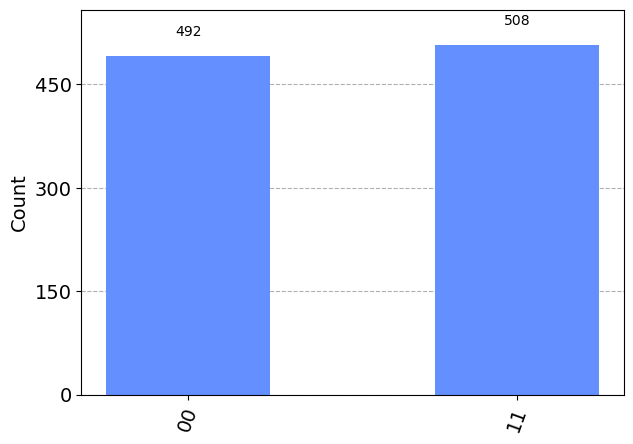

In [12]:
plot_histogram(results)

Now it's your turn to make create the other three bell states, which are

$$ \vert \Phi_+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}} $$
$$ \vert \Phi_-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}} $$
$$ \vert \Psi_+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}} $$
$$ \vert \Psi_-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}} $$

In [15]:
# SOLUTIONS

phi_plus = QuantumCircuit(2,2)
phi_plus.h(0)
phi_plus.cx(0,1)
phi_plus.measure([0,1],[0,1])


phi_minus = QuantumCircuit(2,2)
phi_minus.h(0)
phi_minus.cx(0,1)
phi_minus.z(0) # you can flip 1 in this case too, but not both obviously
phi_minus.measure([0,1],[0,1])


psi_plus = QuantumCircuit(2,2)
psi_plus.h(0)
psi_plus.cx(0,1)
psi_plus.x(0) 
psi_plus.measure([0,1],[0,1])


psi_minus = QuantumCircuit(2,2)
psi_minus.h(0)
psi_minus.cx(0,1)
psi_minus.x(0)
psi_minus.z(0)
psi_minus.measure([0,1],[0,1])


bell_states = [phi_plus, phi_minus, psi_plus, psi_minus]

Have a look at them side by side

In [16]:
all_results = []

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i,state in enumerate(bell_states):
    print(results)
    job = qk.execute(state, simulator, shots=1000)
    all_results.append(job.result().get_counts(state))
    plot_histogram(all_results[-1], ax=axes[int(i/2),i%2])

How can you distinguish $|\Phi_+\rangle$ and $|\Phi_-\rangle$? (and
similarly $|\Psi_+\rangle$ and $|\Psi_-\rangle$)

You can play around with the gates at <https://quantum.ibm.com/composer>.
We'll look at the example with $|\Phi_+\rangle$ and $|\Phi_-\rangle$.

In [17]:
# Solution: change basis

phi_plus = QuantumCircuit(2,2)
phi_plus.h(0)
phi_plus.cx(0,1)
phi_plus.h(0)
phi_plus.h(1)
phi_plus.measure([0,1],[0,1])


phi_minus = QuantumCircuit(2,2)
phi_minus.h(0)
phi_minus.cx(0,1)
phi_minus.z(0) # you can flip 1 in this case too, but not both obviously
phi_minus.h(0)
phi_minus.h(1)
phi_minus.measure([0,1],[0,1])

for state in [phi_plus, phi_minus]:
    job = qk.execute(state, simulator, shots=1000)
    print(job.result().get_counts(state))
    plot_histogram(job.result().get_counts(state))

## Testing the Bell states

In [18]:
from qiskit import QuantumCircuit, transpile, assemble, IBMQ
from qiskit.visualization import circuit_drawer
import qiskit_aer
import matplotlib.pyplot as plt

# Create a quantum circuit with two qubits
bell_circuit = QuantumCircuit(2, 2)

# Apply Hadamard gate to the first qubit
bell_circuit.h(0)

# Apply a CNOT gate with the first qubit as the control and the second qubit as the target
bell_circuit.cx(0, 1)

# Add measurements to the circuit
bell_circuit.measure([0, 1], [0, 1])

# Visualize the circuit
print("Quantum Circuit:")
print(bell_circuit)

## Running the calculations

In [19]:
# Number of shots
num_shots = 10000

# Simulate the circuit using the Aer simulator
simulator = qiskit_aer.Aer.get_backend('qasm_simulator')

# Transpile the circuit for the simulator
transpiled_circuit = transpile(bell_circuit, simulator)

# Execute the transpiled circuit on the simulator with the specified number of shots
result = simulator.run(transpiled_circuit, shots=num_shots).result()

# Get measurement counts
counts = result.get_counts(bell_circuit)

# Get and print the measurement results
counts = result.get_counts(bell_circuit)
print("\nMeasurement Results:")
print(counts)

## Then plotting the histogram over counts

In [20]:
# Plot the histogram using Matplotlib
plt.bar(counts.keys(), counts.values())
plt.title('Bell State Measurement Results')
plt.ylabel('Counts')
plt.show()

## Getting serious, Quantum Simulator with Hardware noise model

In [21]:
from qiskit import QuantumCircuit, transpile, assemble, Aer, IBMQ
from qiskit.visualization import plot_histogram
from qiskit.providers.aer.noise import NoiseModel

# you will not be able to run unless you provide your token here
api_token = 'your_api_token'
# Load your IBM Quantum account
IBMQ.save_account(api_token, overwrite=True)  # This stores your credentials locally
IBMQ.load_account()
# Get the least busy backend
provider = IBMQ.get_provider(hub='ibm-q', group ='open', project='main')
#backend = provider.get_backend('your_preferred_backend')
backend = provider.get_backend('ibm_osaka')

# Get the noise model for the selected backend
noise_model = NoiseModel.from_backend(backend)

# Create a quantum circuit with two qubits
bell_circuit = QuantumCircuit(2, 2)

# Apply Hadamard gate to the first qubit
bell_circuit.h(0)

# Apply a CNOT gate with the first qubit as the control and the second qubit as the target
bell_circuit.cx(0, 1)

# Add measurements to the circuit
bell_circuit.measure([0, 1], [0, 1])

# Visualize the circuit
print("Quantum Circuit:")
print(bell_circuit)

## Then run and visualize it

In [22]:
# Number of shots
num_shots = 10000

# Simulate the circuit using the Aer simulator with the noise model
simulator = Aer.get_backend('qasm_simulator')
noisy_transpiled_circuit = transpile(bell_circuit, simulator, optimization_level=0)
noisy_circuit = assemble(noisy_transpiled_circuit, shots=num_shots, noise_model=noise_model)

# Execute the noisy circuit on the simulator
result = simulator.run(noisy_circuit).result()

# Get and print the measurement results
counts = result.get_counts(bell_circuit)
print("\nMeasurement Results:")
print(counts)
# Plot the histogram using Matplotlib
plot_histogram(counts, title='Bell State Measurement Results')

## And without the noise model

In [23]:
# Provide your IBM Quantum Experience API token here
api_token = 'your_api_token'
# Load your IBM Quantum account
IBMQ.save_account(api_token, overwrite=True)  # This stores your credentials locally
IBMQ.load_account()

# Get the least busy backend
#provider = IBMQ.get_provider(hub='your_hub', group='your_group', project='your_project')
provider = IBMQ.get_provider(hub='ibm-q', group ='open', project='main')
#backend = provider.get_backend('your_preferred_backend')
backend = provider.get_backend('ibm_osaka')

# Create a quantum circuit with two qubits
bell_circuit = QuantumCircuit(2, 2)

# Apply Hadamard gate to the first qubit
bell_circuit.h(0)

# Apply a CNOT gate with the first qubit as the control and the second qubit as the target
bell_circuit.cx(0, 1)

# Add measurements to the circuit
bell_circuit.measure([0, 1], [0, 1])

# Transpile the circuit for the chosen backend
transpiled_circuit = transpile(bell_circuit, backend)

# Execute the transpiled circuit on the IBM Quantum computer
qobj = assemble(transpiled_circuit, shots=1024)  # You can adjust the number of shots
result = backend.run(qobj).result()

# Get measurement counts
counts = result.get_counts(bell_circuit)
print("\nMeasurement Results:")
print(counts)

# Plot the histogram using Matplotlib
plt.bar(counts.keys(), counts.values())
plt.title('Bell State Measurement Results')
plt.ylabel('Counts')
plt.show()